# Taller 4 — Generación de texto con GPT aplicada a issues de GitHub

## Generación de incidencias técnicas a partir de issues reales de GitHub

Este notebook desarrolla un caso de **generación de texto** utilizando un modelo tipo GPT y un dataset real de incidencias de software.

La pregunta de investigación es si un modelo pequeño puede aprender patrones lingüísticos de incidencias reales y producir continuaciones coherentes con ese dominio.

### Fuente de datos

Se utiliza el dataset público de Hugging Face:

**`noamaanMulla-03/datasets-issues`**

El dataset fue construido a partir de la API REST de GitHub y contiene issues y pull requests reales del repositorio `huggingface/datasets`. Para este taller se utilizan únicamente los **issues reales**, excluyendo pull requests.

Fuente: https://huggingface.co/datasets/noamaanMulla-03/datasets-issues

### Pregunta de investigación

> **¿Puede un modelo tipo GPT aprender los patrones lingüísticos presentes en incidencias reales de proyectos de software y generar nuevos textos coherentes con ese dominio?**

Como segunda pregunta experimental:

> **¿Cómo cambia el desempeño al comparar dos capacidades del modelo y distintas estrategias de decodificación?**

En todo el notebook se conserva el enfoque autoregresivo: los tokens anteriores se utilizan para predecir el siguiente token.

# 1. Objetivos

## Objetivo general

Construir y evaluar un modelo generativo tipo GPT capaz de aprender patrones textuales presentes en incidencias reales de proyectos de software.

## Objetivos específicos

1. Cargar automáticamente un dataset real desde Hugging Face.
2. Seleccionar únicamente issues y excluir pull requests.
3. Realizar un EDA del corpus y justificar la longitud de contexto.
4. Preparar el texto de títulos y descripciones con un token EOS explícito.
5. Registrar `<TITLE>` y `<BODY>` como tokens especiales.
6. Entrenar dos configuraciones de un modelo GPT pequeño con early stopping.
7. Comparar pérdida, perplexity y número de parámetros.
8. Analizar el efecto de distintas estrategias de decodificación.
9. Generar nuevas incidencias a partir de prompts.
10. Dejar una demo interactiva para ejecución manual.

# 2. Alcance y criterio del caso

La tarea es **generación de texto**, no clasificación.

La unidad de información será una incidencia real de GitHub representada de esta forma:

```text
<TITLE> título del issue
<BODY> descripción del issue
<eos>
```

El modelo aprenderá a predecir el siguiente token utilizando únicamente los tokens anteriores. Las etiquetas del repositorio se revisan como parte del EDA, pero no se utilizan como objetivo de entrenamiento.

# 3. Instalación e importaciones

La primera celda instala las dependencias necesarias para cargar los datos, entrenar el modelo y visualizar los resultados.

In [79]:
%pip install -q datasets transformers pandas numpy matplotlib torch scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [80]:
import os
import re
import math
import time
import random
from copy import deepcopy
from pathlib import Path
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import GPT2TokenizerFast, GPT2Config, GPT2LMHeadModel

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Dispositivo:", DEVICE)
print("PyTorch:", torch.__version__)

Dispositivo: mps
PyTorch: 2.14.0


# 4. Carga automática del dataset real

Una decisión importante para la **reproducibilidad** es no depender de una ruta local.

El notebook descarga el dataset directamente desde Hugging Face:

```python
load_dataset("noamaanMulla-03/datasets-issues")
```

De acuerdo con la tarjeta del dataset, contiene 8.084 filas entre issues y pull requests.  
La columna `is_pull_request` permite separar ambos tipos.

In [81]:
DATASET_ID = "noamaanMulla-03/datasets-issues"

hf_dataset = load_dataset(
    DATASET_ID,
    split="train"
)

print(hf_dataset)
print("\nColumnas disponibles:")
print(hf_dataset.column_names)

Dataset({
    features: ['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'assignee', 'author_association', 'issue_field_values', 'type', 'active_lock_reason', 'draft', 'pull_request', 'body', 'closed_by', 'reactions', 'timeline_url', 'performed_via_github_app', 'state_reason', 'sub_issues_summary', 'issue_dependencies_summary', 'pinned_comment', 'is_pull_request', 'comments_text'],
    num_rows: 8084
})

Columnas disponibles:
['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'assignee', 'author_association', 'issue_field_values', 'type', 'active_lock_reason', 'draft', 'pull_request', 'body', 'closed_by', 'reactions', 'timel

In [82]:
df_raw = hf_dataset.to_pandas()

print("Filas totales:", len(df_raw))
print("Columnas:", len(df_raw.columns))

display(
    df_raw[
        ["number", "title", "body", "state", "is_pull_request"]
    ].head()
)

Filas totales: 8084
Columnas: 38


,number,title,body,state,is_pull_request
0,20,remove boto3 and promise dependencies,"With the new download manager, we don't need `...",closed,True
1,17,Add Pandas as format type,As detailed in the title ^^,closed,True
2,22,adding bleu score code,this PR add the BLEU score metric to the lib. ...,closed,True
3,5,ValueError when a split is empty,"When a split is empty either TEST, VALIDATION ...",closed,False
4,6,Error when citation is not given in the Datase...,The following error is raised when the `citati...,closed,False


# 5. Selección de issues reales y control de calidad

El endpoint de GitHub retorna tanto issues como pull requests. Para que el caso se enfoque en incidencias, se conservan únicamente las filas donde:

```text
is_pull_request == False
```

También se eliminan títulos vacíos y duplicados exactos.

In [83]:
df = df_raw[
    df_raw["is_pull_request"] == False
].copy()

df["title"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["body"] = (
    df["body"]
    .fillna("")
    .astype(str)
)

df = df[
    df["title"].str.len() > 0
].copy()

print("Issues reales antes de eliminar duplicados:", len(df))

duplicados = df["title"].str.lower().duplicated().sum()
print("Títulos duplicados:", duplicados)

df = (
    df
    .assign(_title_key=df["title"].str.lower())
    .drop_duplicates("_title_key")
    .drop(columns="_title_key")
    .reset_index(drop=True)
)

print("Issues finales disponibles:", len(df))

Issues reales antes de eliminar duplicados: 3293
Títulos duplicados: 17
Issues finales disponibles: 3276


# 6. EDA — Análisis exploratorio del corpus

El EDA busca responder:

- ¿Cuántos issues tenemos?
- ¿Cuántos tienen descripción?
- ¿Qué tan largos son?
- ¿Cuáles son las palabras y bigramas frecuentes?
- ¿Qué labels aparecen con mayor frecuencia?

Esto permite entender el corpus antes de entrenar.

In [84]:
df["title_words"] = df["title"].str.split().str.len()
df["body_words"] = df["body"].str.split().str.len()
df["has_body"] = df["body"].str.strip().str.len() > 0

print("Issues:", len(df))
print("Con body:", int(df["has_body"].sum()))
print("Sin body:", int((~df["has_body"]).sum()))

display(
    df[["title_words", "body_words"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Issues: 3276
Con body: 3254
Sin body: 22


,title_words,body_words
count,3276.000000,3276.00000
mean,7.419719,184.86569
std,3.772131,302.24748
min,1.000000,0.00000
50%,7.000000,128.00000
75%,9.000000,222.00000
90%,12.000000,367.00000
95%,14.000000,492.25000
99%,18.000000,1034.75000
max,44.000000,12223.00000


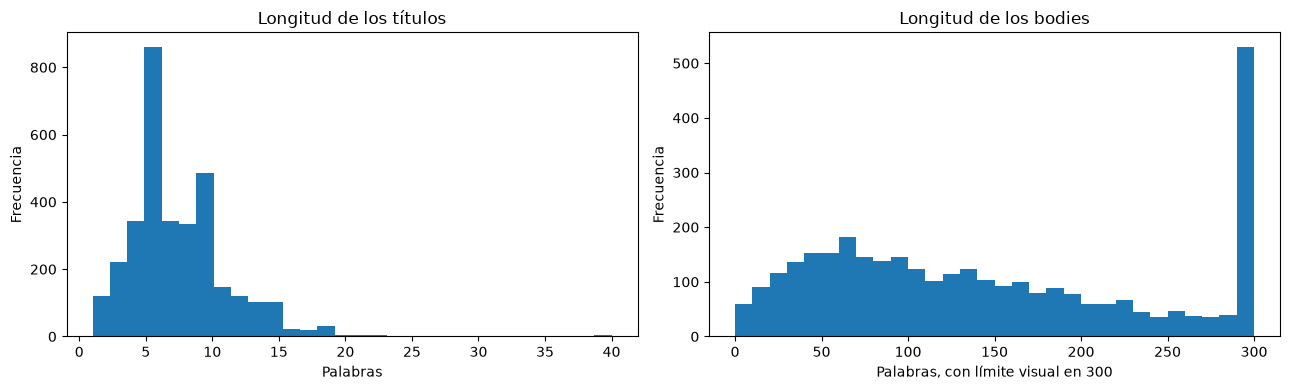

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["title_words"].clip(upper=40), bins=30)
axes[0].set_title("Longitud de los títulos")
axes[0].set_xlabel("Palabras")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df["body_words"].clip(upper=300), bins=30)
axes[1].set_title("Longitud de los bodies")
axes[1].set_xlabel("Palabras, con límite visual en 300")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Lectura de las longitudes

Los títulos son, en general, breves, mientras que los bodies presentan una dispersión mayor y una cola de documentos extensos. Por eso el cuerpo se limita a una porción inicial y la longitud final se revisa nuevamente después de tokenizar.

,token,frecuencia
0,dataset,1004
1,not,361
2,datasets,357
3,error,294
4,add,206
5,loading,204
6,load_dataset,163
7,data,161
8,load,150
9,cannot,127


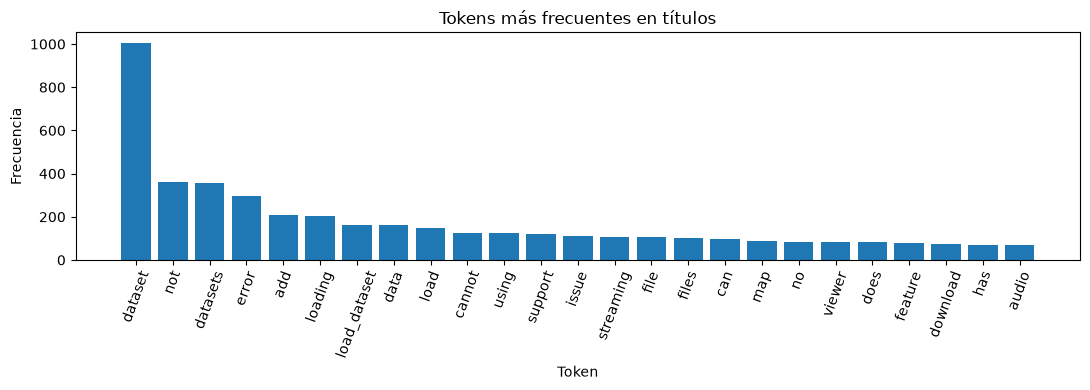

In [86]:
def normalizar_para_eda(texto):
    texto = str(texto).lower()
    texto = re.sub(r"https?://\S+", " ", texto)
    texto = re.sub(r"[^a-z0-9_+#.\-\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

STOPWORDS_EDA = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on",
    "for", "with", "is", "are", "was", "were", "be", "been",
    "by", "from", "at", "as", "it", "this", "that", "these",
    "those", "into", "i", "we", "you", "when", "if"
}

tokens = []

for title in df["title"]:
    for token in normalizar_para_eda(title).split():
        if token not in STOPWORDS_EDA and len(token) > 1:
            tokens.append(token)

top_words = pd.DataFrame(
    Counter(tokens).most_common(25),
    columns=["token", "frecuencia"]
)

display(top_words)

plt.figure(figsize=(11, 4))
plt.bar(
    top_words["token"],
    top_words["frecuencia"]
)
plt.title("Tokens más frecuentes en títulos")
plt.xlabel("Token")
plt.ylabel("Frecuencia")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [87]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=3,
    stop_words="english"
)

X_bigrams = vectorizer.fit_transform(df["title"])
freq = np.asarray(X_bigrams.sum(axis=0)).ravel()
names = np.array(vectorizer.get_feature_names_out())

idx = np.argsort(freq)[::-1][:20]

bigrams_df = pd.DataFrame({
    "bigrama": names[idx],
    "frecuencia": freq[idx]
})

display(bigrams_df)

,bigrama,frecuencia
0,dataset viewer,76
1,viewer issue,56
2,dataset map,44
3,loading dataset,32
4,error loading,32
5,feature request,30
6,pyarrow lib,25
7,does work,25
8,load dataset,24
9,map function,21


### Lectura de tokens, bigramas y labels

Los tokens más frecuentes muestran el vocabulario técnico dominante del repositorio. Los bigramas permiten observar combinaciones habituales de títulos, como solicitudes de soporte, errores y cambios en datasets. Los labels se conservan como referencia descriptiva del dominio, pero no se utilizan como objetivo del modelo.

## 6.1 Labels reales del repositorio

In [88]:
def extraer_label_names(labels):
    if labels is None:
        return []

    if isinstance(labels, np.ndarray):
        labels = labels.tolist()

    if not isinstance(labels, (list, tuple)):
        return []

    names = []

    for item in labels:
        if isinstance(item, dict):
            name = item.get("name")
            if name:
                names.append(str(name))

    return names

all_labels = []

for labels in df["labels"]:
    all_labels.extend(
        extraer_label_names(labels)
    )

top_labels = pd.DataFrame(
    Counter(all_labels).most_common(15),
    columns=["label", "frecuencia"]
)

display(top_labels)

,label,frecuencia
0,bug,706
1,enhancement,501
2,dataset request,161
3,dataset-viewer,86
4,dataset bug,74
5,good first issue,53
6,duplicate,30
7,generic discussion,27
8,documentation,27
9,question,24


# 7. Construcción del corpus para generación

Se combinan `title` y `body`.

Para evitar que descripciones extremadamente largas dominen el corpus, se conserva una porción inicial del body. Esta decisión no genera datos nuevos; únicamente limita la longitud de cada documento.

Formato:

```text
<TITLE> ...
<BODY> ...
```

In [89]:
MAX_BODY_CHARS = 1200

def limpiar_body(texto):
    texto = str(texto)

    texto = re.sub(
        r"https?://\S+",
        "<URL>",
        texto
    )

    texto = re.sub(
        r"```.*?```",
        " <CODE> ",
        texto,
        flags=re.DOTALL
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto[:MAX_BODY_CHARS]


tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
num_special_tokens = tokenizer.add_special_tokens({
    "additional_special_tokens": ["<TITLE>", "<BODY>"],
    "pad_token": "<|pad|>"
})


def construir_documento(row):
    title = str(row["title"]).strip()
    body = limpiar_body(row["body"])
    partes = [f"<TITLE> {title}"]

    if body:
        partes.append(f"<BODY> {body}")

    partes.append(tokenizer.eos_token)
    return "\n".join(partes)


df["text"] = df.apply(
    construir_documento,
    axis=1
)

print("Tokens especiales añadidos:", num_special_tokens)
print("EOS utilizado:", repr(tokenizer.eos_token))
print("PAD utilizado:", repr(tokenizer.pad_token))
print("EOS y PAD distintos:", tokenizer.eos_token_id != tokenizer.pad_token_id)
display(
    df[["title", "text"]].head(3)
)

Tokens especiales añadidos: 3
EOS utilizado: '<|endoftext|>'
PAD utilizado: '<|pad|>'
EOS y PAD distintos: True


,title,text
0,ValueError when a split is empty,<TITLE> ValueError when a split is empty\n<BOD...
1,Error when citation is not given in the Datase...,<TITLE> Error when citation is not given in th...
2,[Feature] More dataset outputs,<TITLE> [Feature] More dataset outputs\n<BODY>...


# 8. División Train / Validation / Test

Se utiliza una división reproducible:

- **80 % Train**
- **10 % Validation**
- **10 % Test**

Test se reserva para la evaluación final.

In [90]:
indices = np.arange(len(df))

rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n = len(indices)
n_train = int(n * 0.80)
n_val = int(n * 0.10)

idx_train = indices[:n_train]
idx_val = indices[n_train:n_train + n_val]
idx_test = indices[n_train + n_val:]

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2620
Validation: 327
Test: 329


# 9. Tokenización

Se utiliza `GPT2TokenizerFast` para convertir el texto en tokens subword de GPT-2. `<TITLE>` y `<BODY>` se registran como tokens especiales de una sola unidad. El tokenizador utiliza un PAD separado del EOS.

La longitud de contexto se selecciona a partir de la distribución tokenizada del corpus. La celda siguiente muestra la tabla, el histograma y la regla utilizada para elegir el bloque.

,métrica,tokens
0,media,177.67
1,mediana,155.00
2,percentil 75,249.00
3,percentil 90,329.00
4,percentil 95,379.25
5,% > 96,73.41
6,% > 128,60.07
7,% > 192,38.58
8,% > 256,23.47


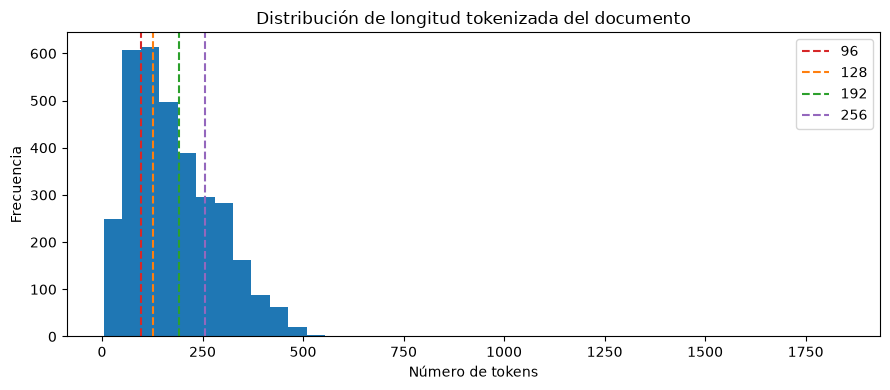

BLOCK_SIZE seleccionado: 256 tokens (cubre 76.53% del corpus).
Criterio: mayor candidato disponible porque ninguno alcanza 90%.

Comprobación de marcadores:
<TITLE> -> [50258] | tokens: ['<TITLE>']
<BODY> -> [50259] | tokens: ['<BODY>']

Ejemplo tokenizado:
<TITLE> Consistent caching between python and jupyter
<BODY> ### Feature request I hope this is not my mistake, currently if I use `load_dataset` from a python session on a custom dataset to do the preprocessing, it will be saved in the cache and in other python sessions it will be loaded from the cache, however calling the same from a jupyter notebook does not work, meaning the preprocessing starts from scratch. If adjusting the hashes is impossible, is there a way to manually set dataset finge
Primeros IDs: [50258, 3515, 7609, 40918, 1022, 21015, 290, 474, 929, 88, 353, 198, 50259, 44386, 27018, 2581, 314, 2911, 428, 318, 407, 616, 7457, 11, 3058, 611, 314, 779, 4600, 2220]
Número de tokens: 188
Termina en EOS sin truncar: True

C

In [108]:
# 9. Tokenización y selección de BLOCK_SIZE

# Se amplía solo el límite informativo del tokenizador para medir documentos completos sin warning.
tokenizer.model_max_length = int(1e9)

document_lengths = np.array([
    len(tokenizer.encode(text, add_special_tokens=False))
    for text in df["text"]
])

length_summary = pd.DataFrame({
    "métrica": [
        "media", "mediana", "percentil 75", "percentil 90", "percentil 95",
        "% > 96", "% > 128", "% > 192", "% > 256"
    ],
    "tokens": [
        document_lengths.mean(),
        np.percentile(document_lengths, 50),
        np.percentile(document_lengths, 75),
        np.percentile(document_lengths, 90),
        np.percentile(document_lengths, 95),
        100 * np.mean(document_lengths > 96),
        100 * np.mean(document_lengths > 128),
        100 * np.mean(document_lengths > 192),
        100 * np.mean(document_lengths > 256)
    ]
})

display(length_summary.round(2))

plt.figure(figsize=(9, 4))
plt.hist(document_lengths, bins=40)
plt.axvline(96, color="tab:red", linestyle="--", label="96")
plt.axvline(128, color="tab:orange", linestyle="--", label="128")
plt.axvline(192, color="tab:green", linestyle="--", label="192")
plt.axvline(256, color="tab:purple", linestyle="--", label="256")
plt.title("Distribución de longitud tokenizada del documento")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

candidatos_block_size = [128, 192, 256]
coberturas_block = {
    block_size: float(np.mean(document_lengths <= block_size))
    for block_size in candidatos_block_size
}
block_size_suficiente = [
    block_size
    for block_size in candidatos_block_size
    if coberturas_block[block_size] >= 0.90
]

if block_size_suficiente:
    BLOCK_SIZE = min(block_size_suficiente)
    criterio_block = "menor candidato con cobertura de al menos 90%"
else:
    BLOCK_SIZE = max(candidatos_block_size)
    criterio_block = "mayor candidato disponible porque ninguno alcanza 90%"

block_coverage = 100 * coberturas_block[BLOCK_SIZE]
print(f"BLOCK_SIZE seleccionado: {BLOCK_SIZE} tokens (cubre {block_coverage:.2f}% del corpus).")
print(f"Criterio: {criterio_block}.")

print("\nComprobación de marcadores:")
for marker in ["<TITLE>", "<BODY>"]:
    marker_ids = tokenizer.encode(marker, add_special_tokens=False)
    print(marker, "->", marker_ids, "| tokens:", tokenizer.tokenize(marker))

print("\nEjemplo tokenizado:")
ejemplo = train_df["text"].iloc[0]
ids_ejemplo = tokenizer.encode(ejemplo, add_special_tokens=False)
print(ejemplo[:500])
print("Primeros IDs:", ids_ejemplo[:30])
print("Número de tokens:", len(ids_ejemplo))
print("Termina en EOS sin truncar:", ids_ejemplo[-1] == tokenizer.eos_token_id)
print("\nCon la misma configuración los resultados deberían ser cercanos, aunque pueden existir pequeñas variaciones entre CPU, CUDA y MPS.")

# 10. Dataset autoregresivo

En GPT, la etiqueta no es una clase. El objetivo es reconstruir la secuencia desplazando internamente la predicción; los tokens de padding se excluyen de la pérdida.

In [109]:
class GitHubIssuesTextDataset(Dataset):

    def __init__(
        self,
        texts,
        tokenizer,
        block_size
    ):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.block_size = block_size

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer(
            text,
            add_special_tokens=False,
            return_attention_mask=False
        )
        token_ids = encoded["input_ids"]

        if len(token_ids) > self.block_size:
            token_ids = token_ids[:self.block_size - 1]
            token_ids.append(self.tokenizer.eos_token_id)

        padding_length = self.block_size - len(token_ids)
        input_ids = torch.tensor(
            token_ids + [self.tokenizer.pad_token_id] * padding_length,
            dtype=torch.long
        )
        attention_mask = torch.tensor(
            [1] * len(token_ids) + [0] * padding_length,
            dtype=torch.long
        )
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }


train_dataset = GitHubIssuesTextDataset(train_df["text"], tokenizer, BLOCK_SIZE)
val_dataset = GitHubIssuesTextDataset(val_df["text"], tokenizer, BLOCK_SIZE)
test_dataset = GitHubIssuesTextDataset(test_df["text"], tokenizer, BLOCK_SIZE)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("labels:", batch["labels"].shape)

muestras_verificadas = min(10, len(train_dataset))
eos_finales = 0
padding_labels_correctos = 0
for indice in range(muestras_verificadas):
    documento = train_dataset[indice]
    longitud_real = int(documento["attention_mask"].sum())
    eos_finales += int(
        documento["input_ids"][longitud_real - 1].item() == tokenizer.eos_token_id
    )
    padding = documento["attention_mask"] == 0
    padding_labels_correctos += int(
        bool(torch.all(documento["labels"][padding] == -100))
    )

print(f"Documentos verificados con EOS final: {eos_finales}/{muestras_verificadas}")
print(
    "Documentos con labels de padding correctos: "
    f"{padding_labels_correctos}/{muestras_verificadas}"
)

input_ids: torch.Size([16, 256])
attention_mask: torch.Size([16, 256])
labels: torch.Size([16, 256])
Documentos verificados con EOS final: 10/10
Documentos con labels de padding correctos: 10/10


# 11. Arquitectura GPT del experimento

Se construye un GPT pequeño con embeddings de tokens y posiciones, atención causal, bloques Transformer, feed-forward, normalización y una capa final de predicción sobre el vocabulario.

Se comparan dos configuraciones de la misma arquitectura para analizar el efecto de la profundidad.

In [110]:
EXPERIMENTOS = [
    {
        "id": "E1",
        "nombre": "Mini-GPT 2 capas",
        "n_layer": 2,
        "n_head": 4,
        "n_embd": 128,
        "dropout": 0.10,
        "learning_rate": 3e-4,
        "max_epochs": 10,
        "patience": 2
    },
    {
        "id": "E2",
        "nombre": "Mini-GPT 4 capas",
        "n_layer": 4,
        "n_head": 4,
        "n_embd": 128,
        "dropout": 0.10,
        "learning_rate": 3e-4,
        "max_epochs": 10,
        "patience": 2
    }
]

display(pd.DataFrame(EXPERIMENTOS))

,id,nombre,n_layer,n_head,n_embd,dropout,learning_rate,max_epochs,patience
0,E1,Mini-GPT 2 capas,2,4,128,0.1,0.0003,10,2
1,E2,Mini-GPT 4 capas,4,4,128,0.1,0.0003,10,2


In [111]:
def crear_modelo(exp):
    config = GPT2Config(
        vocab_size=len(tokenizer),
        n_positions=BLOCK_SIZE,
        n_ctx=BLOCK_SIZE,
        n_embd=exp["n_embd"],
        n_layer=exp["n_layer"],
        n_head=exp["n_head"],
        resid_pdrop=exp["dropout"],
        embd_pdrop=exp["dropout"],
        attn_pdrop=exp["dropout"],
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    model = GPT2LMHeadModel(config)
    model.resize_token_embeddings(len(tokenizer))
    return model


modelo_demo = crear_modelo(EXPERIMENTOS[0])
params = sum(p.numel() for p in modelo_demo.parameters())
print(f"Parámetros E1: {params:,}")
del modelo_demo

Parámetros E1: 6,862,848


# 12. Funciones de entrenamiento y evaluación

La métrica principal es la loss autoregresiva. También se calcula perplexity como `exp(loss)`; una menor perplexity indica una mejor predicción de los tokens del conjunto evaluado.

In [112]:
def evaluar_lm(model, loader):
    model.eval()
    losses = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            losses.append(outputs.loss.item())

    mean_loss = float(np.mean(losses))
    return {
        "loss": mean_loss,
        "perplexity": float(math.exp(min(mean_loss, 20)))
    }


def entrenar_lm(
    model,
    train_loader,
    val_loader,
    learning_rate,
    max_epochs,
    patience=2
):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    history = []
    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics = evaluar_lm(model, val_loader)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_perplexity": val_metrics["perplexity"]
        })

        print(
            f"Epoch {epoch:02d} | Train loss: {train_loss:.4f} | "
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val perplexity: {val_metrics['perplexity']:.2f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping en época {epoch}.")
                break

    model.load_state_dict(best_state)
    elapsed = time.time() - start
    final_val = evaluar_lm(model, val_loader)
    return model, pd.DataFrame(history), final_val, elapsed, best_epoch

# 13. Entrenamiento de los experimentos

Ambos modelos utilizan el mismo corpus, split, tokenizador, `BLOCK_SIZE`, optimizador y learning rate. Se ejecutan como máximo 10 épocas y se detienen si la validation loss no mejora durante 2 épocas consecutivas. El estado restaurado es siempre el de menor validation loss.

In [113]:
modelos = {}
historias = {}
resultados = []

for exp in EXPERIMENTOS:
    print("\n" + "=" * 75)
    print(exp["id"], "-", exp["nombre"])
    print("=" * 75)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = crear_modelo(exp)
    total_params = sum(p.numel() for p in model.parameters())

    model, history, val_metrics, elapsed, best_epoch = entrenar_lm(
        model,
        train_loader,
        val_loader,
        learning_rate=exp["learning_rate"],
        max_epochs=exp["max_epochs"],
        patience=exp["patience"]
    )

    modelos[exp["nombre"]] = model
    historias[exp["nombre"]] = history
    resultados.append({
        "modelo": exp["nombre"],
        "capas": exp["n_layer"],
        "parametros": total_params,
        "epocas_ejecutadas": len(history),
        "epoca_seleccionada": best_epoch,
        "val_loss": val_metrics["loss"],
        "val_perplexity": val_metrics["perplexity"],
        "tiempo_segundos": elapsed
    })

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values("val_loss")
    .reset_index(drop=True)
)

display(resultados_df)
print("Los tiempos dependen del hardware y se incluyen solo como referencia de esta ejecución.")


E1 - Mini-GPT 2 capas
Epoch 01 | Train loss: 7.7446 | Val loss: 6.4390 | Val perplexity: 625.79
Epoch 02 | Train loss: 5.8462 | Val loss: 5.4353 | Val perplexity: 229.35
Epoch 03 | Train loss: 5.0559 | Val loss: 4.9703 | Val perplexity: 144.07
Epoch 04 | Train loss: 4.6607 | Val loss: 4.7503 | Val perplexity: 115.62
Epoch 05 | Train loss: 4.4179 | Val loss: 4.5941 | Val perplexity: 98.90
Epoch 06 | Train loss: 4.2503 | Val loss: 4.4869 | Val perplexity: 88.84
Epoch 07 | Train loss: 4.1092 | Val loss: 4.4094 | Val perplexity: 82.22
Epoch 08 | Train loss: 3.9942 | Val loss: 4.3376 | Val perplexity: 76.52
Epoch 09 | Train loss: 3.8951 | Val loss: 4.2782 | Val perplexity: 72.11
Epoch 10 | Train loss: 3.8038 | Val loss: 4.2441 | Val perplexity: 69.69

E2 - Mini-GPT 4 capas
Epoch 01 | Train loss: 7.6803 | Val loss: 6.2658 | Val perplexity: 526.26
Epoch 02 | Train loss: 5.6738 | Val loss: 5.3435 | Val perplexity: 209.25
Epoch 03 | Train loss: 4.9736 | Val loss: 4.9268 | Val perplexity: 137.9

,modelo,capas,parametros,epocas_ejecutadas,epoca_seleccionada,val_loss,val_perplexity,tiempo_segundos
0,Mini-GPT 4 capas,4,7259392,10,10,4.229661,68.693952,232.97961
1,Mini-GPT 2 capas,2,6862848,10,10,4.244067,69.690716,197.29132


Los tiempos dependen del hardware y se incluyen solo como referencia de esta ejecución.


**Interpretación de la comparación.** La selección se hace con validation loss y validation perplexity. Una diferencia pequeña entre configuraciones debe interpretarse con cautela: en este corpus no basta para afirmar que una mayor profundidad sea siempre mejor. Los tiempos se reportan como referencia de la corrida concreta, porque no son comparables entre máquinas.

# 14. Curvas de entrenamiento

Las curvas muestran la evolución de train loss y validation loss hasta la detención o el máximo de épocas.

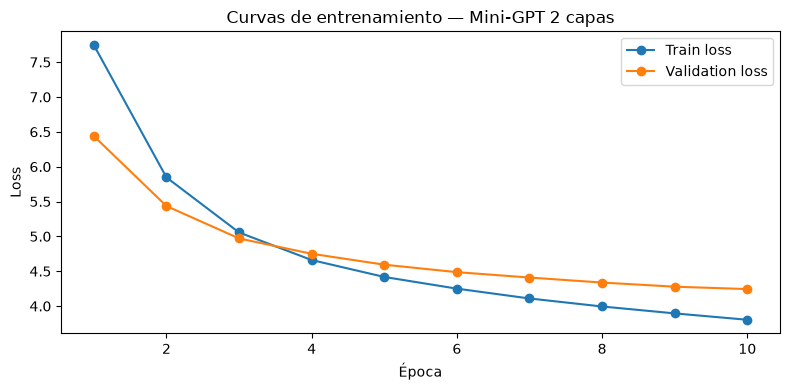

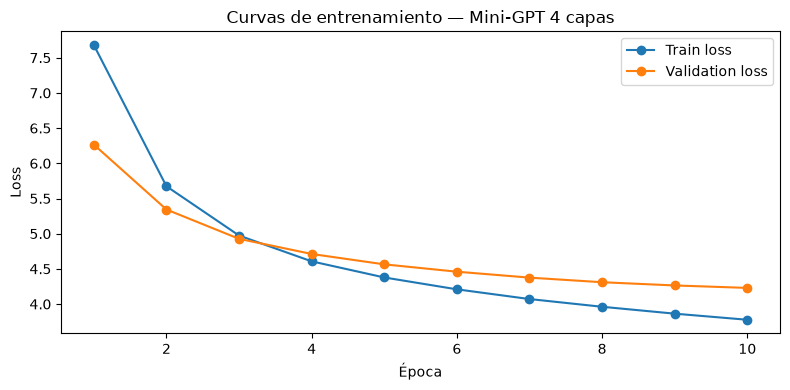

In [114]:
for nombre, history in historias.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.title(
        f"Curvas de entrenamiento — {nombre}"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 15. Selección del mejor modelo

El modelo se selecciona exclusivamente con validation loss. Test no participa en la selección.

In [115]:
MEJOR_NOMBRE = resultados_df.iloc[0][
    "modelo"
]

mejor_modelo = modelos[
    MEJOR_NOMBRE
]

print(
    "Modelo seleccionado:",
    MEJOR_NOMBRE
)

Modelo seleccionado: Mini-GPT 4 capas


# 16. Evaluación final en Test

El conjunto de test se utiliza una sola vez después de seleccionar el modelo con validation loss.

In [116]:
test_metrics = evaluar_lm(
    mejor_modelo,
    test_loader
)

print("TEST LOSS:", round(
    test_metrics["loss"],
    4
))

print("TEST PERPLEXITY:", round(
    test_metrics["perplexity"],
    2
))

TEST LOSS: 4.0919
TEST PERPLEXITY: 59.85


**Interpretación de Test.** Los valores de test se comparan con validación como referencia de generalización. La perplexity resume la dificultad de predecir los tokens del conjunto evaluado y no sustituye la revisión cualitativa de los textos generados.

# 17. Generación autoregresiva

Durante la generación, el modelo recibe un prompt y predice nuevos tokens de manera autoregresiva. Se comparan greedy decoding, temperatura, top-k, top-p y temperatura + top-k con el mismo prompt y el mismo número de tokens nuevos.

In [117]:
def generar_texto(
    prompt,
    model,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_k=40,
    top_p=1.0
):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs["input_ids"].to(DEVICE)
    attention_mask = inputs["attention_mask"].to(DEVICE)

    kwargs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "do_sample": do_sample
    }

    if do_sample:
        kwargs["temperature"] = temperature
        kwargs["top_k"] = top_k
        kwargs["top_p"] = top_p

    with torch.no_grad():
        output = model.generate(**kwargs)

    termina_en_eos = output[0, -1].item() == tokenizer.eos_token_id
    texto = tokenizer.decode(output[0], skip_special_tokens=True)
    return texto, termina_en_eos


def distinct_n(texto, n=1):
    tokens = normalizar_para_eda(texto).split()
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return len(set(ngrams)) / len(ngrams)

# 18. Comparación de estrategias de decodificación

Se mantiene el mismo prompt, la misma semilla para cada estrategia y `max_new_tokens`. Distinct-1 y Distinct-2 se utilizan como indicadores descriptivos de diversidad, no como una medida suficiente de calidad.

In [118]:
prompt_comparacion = "<TITLE> Add support for"
MAX_NEW_TOKENS = 45

estrategias_decodificacion = [
    {
        "nombre": "Greedy",
        "do_sample": False,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 1.0
    },
    {
        "nombre": "Temperatura",
        "do_sample": True,
        "temperature": 0.7,
        "top_k": 0,
        "top_p": 1.0
    },
    {
        "nombre": "Top-k",
        "do_sample": True,
        "temperature": 1.0,
        "top_k": 40,
        "top_p": 1.0
    },
    {
        "nombre": "Top-p",
        "do_sample": True,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 0.9
    },
    {
        "nombre": "Temperatura + top-k",
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 40,
        "top_p": 1.0
    }
]

resultados_decodificacion = []

for estrategia in estrategias_decodificacion:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    texto_generado, termina_eos = generar_texto(
        prompt_comparacion,
        mejor_modelo,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=estrategia["do_sample"],
        temperature=estrategia["temperature"],
        top_k=estrategia["top_k"],
        top_p=estrategia["top_p"]
    )

    resultados_decodificacion.append({
        "estrategia": estrategia["nombre"],
        "temperature": estrategia["temperature"],
        "top_k": estrategia["top_k"],
        "top_p": estrategia["top_p"],
        "generacion": texto_generado,
        "Distinct-1": distinct_n(texto_generado, 1),
        "Distinct-2": distinct_n(texto_generado, 2),
        "termina_eos": termina_eos
    })

    print("\n" + "=" * 70)
    print(estrategia["nombre"])
    print("=" * 70)
    print(texto_generado)
    print("Termina en EOS:", termina_eos)

comparacion_decodificacion = pd.DataFrame(resultados_decodificacion)
display(
    comparacion_decodificacion[
        ["estrategia", "temperature", "top_k", "top_p", "Distinct-1", "Distinct-2", "termina_eos"]
    ].round(3)
)


Greedy
 Add support for Dataset
 ## Adding a Dataset - **Name:** *link to the dataset* - **Description:** *link to the dataset* - **Description:** *link to the dataset* -
Termina en EOS: False

Temperatura
 Add support for semanticAD dataset
 ## Adding a Dataset - **Name:** *link to the dataset* - **Description:** *link to the schema of the dataset* - **Data:** *link to the
Termina en EOS: False

Top-k
 Add support for load_dataset(json)
 ### Feature request The documentation for `load_andaset` and is no data in the dataset using `py` and `<URL> This feature of `shard
Termina en EOS: False

Top-p
 Add support for semanticAD method
 ### Describe the bug bug When someone can run the `load_andas dataset location type is no data in the split of schema has there is instance of GPU and pandas' has a dataset
Termina en EOS: False

Temperatura + top-k
 Add support for load_dataset
 Please describe. I'm trying to run the following code to the dataset dataset from the dataset library, it in the

,estrategia,temperature,top_k,top_p,Distinct-1,Distinct-2,termina_eos
0,Greedy,1.0,0,1.0,0.481,0.577,False
1,Temperatura,0.7,0,1.0,0.586,0.750,False
2,Top-k,1.0,40,1.0,0.852,1.000,False
3,Top-p,1.0,0,0.9,0.816,1.000,False
4,Temperatura + top-k,0.8,40,1.0,0.676,0.917,False


### Lectura de las salidas actuales

La celda siguiente resume las repeticiones, los cierres incompletos, la presencia de vocabulario técnico y la terminación en EOS observadas en las salidas de esta ejecución. La tabla de diversidad se interpreta junto con esos textos: un Distinct mayor no implica por sí solo mayor coherencia.

In [119]:
print("Análisis de las salidas actuales:")
terminos_tecnicos = {"dataset", "datasets", "bug", "error", "support", "load_dataset", "issue"}
for item in resultados_decodificacion:
    texto = item["generacion"]
    palabras = normalizar_para_eda(texto).split()
    repeticiones = len(palabras) - len(set(palabras))
    terminos = sorted(set(palabras) & terminos_tecnicos)
    print(
        f"- {item['estrategia']}: {repeticiones} palabras repetidas; "
        f"términos técnicos={terminos or 'ninguno'}; "
        f"termina en EOS={item['termina_eos']}."
    )

Análisis de las salidas actuales:
- Greedy: 14 palabras repetidas; términos técnicos=['dataset', 'support']; termina en EOS=False.
- Temperatura: 12 palabras repetidas; términos técnicos=['dataset', 'support']; termina en EOS=False.
- Top-k: 4 palabras repetidas; términos técnicos=['dataset', 'load_dataset', 'support']; termina en EOS=False.
- Top-p: 7 palabras repetidas; términos técnicos=['bug', 'dataset', 'support']; termina en EOS=False.
- Temperatura + top-k: 12 palabras repetidas; términos técnicos=['bug', 'dataset', 'load_dataset', 'support']; termina en EOS=False.


# 19. Diversidad léxica de las generaciones

Distinct-1 es la proporción de tokens únicos y Distinct-2 la proporción de bigramas únicos. La tabla comparativa se genera con las mismas salidas de las cinco estrategias actuales y se interpreta junto con su coherencia, repeticiones, vocabulario técnico y terminación real en EOS.

# 20. Generación de múltiples incidencias

Se generan varias alternativas a partir de inicios frecuentes del corpus para observar la variabilidad del modelo.

In [120]:
prompts_incidentes = [
    "<TITLE> Error when",
    "<TITLE> Add support for",
    "<TITLE> Improve",
    "<TITLE> Unable to"
]

for prompt in prompts_incidentes:
    print("\n" + "#" * 75)
    print("PROMPT:", prompt)
    print("#" * 75)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    for indice in range(3):
        texto, termina_eos = generar_texto(
            prompt,
            mejor_modelo,
            max_new_tokens=35,
            do_sample=True,
            temperature=0.8,
            top_k=40
        )
        print(f"\nGeneración {indice + 1}:")
        print(texto)
        print("Termina en EOS:", termina_eos)


###########################################################################
PROMPT: <TITLE> Error when
###########################################################################

Generación 1:
 Error when using torch/Dataset
 ## Describe the bug When using the `load_andaset` dataset is no data in the dataset using `py` and
Termina en EOS: False

Generación 2:
 Error when I am trying to load the dataset to load dataset to reproduce the hub
 ## Describe the bug When using a dataset, I'm trying to use the `datas
Termina en EOS: False

Generación 3:
 Error when loading `dataset.load_disk` version
 ### Describe the bug I can't be able to load the dataset and it with the original file, I
Termina en EOS: False

###########################################################################
PROMPT: <TITLE> Add support for
###########################################################################

Generación 1:
 Add support for load_dataset
 Please describe. I'm trying to run the following code 

# 21. Demos de generación

## A. Demo automática

La siguiente celda se ejecuta durante Run All con una semilla fija y produce un output visible. La salida es texto generado por el modelo, no un registro real del corpus.

In [121]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

prompt_demo = "<TITLE> Application fails when"
print("DEMO AUTOMÁTICA — OUTPUT GENERADO")
texto_demo, termina_eos_demo = generar_texto(
    prompt_demo,
    mejor_modelo,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_k=40
)
print(texto_demo)
print("Termina en EOS:", termina_eos_demo)

DEMO AUTOMÁTICA — OUTPUT GENERADO


 Application fails when using torch/Dataset
 ## Describe the bug When using the `load_andaset` and the same data is in the dataset is not work, I am trying to the same data file, the `pus` is
Termina en EOS: False


## B. Demo interactiva opcional

Para probar un prompt propio, ejecutar manualmente `demo_interactiva()` al finalizar.

In [122]:
def demo_interactiva():
    prompt_usuario = input("Escribe el inicio de la incidencia: ").strip()

    if not prompt_usuario.startswith("<TITLE>"):
        prompt_usuario = "<TITLE> " + prompt_usuario

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    resultado, termina_eos = generar_texto(
        prompt_usuario,
        mejor_modelo,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_k=40
    )

    print("\nGENERACIÓN DEL MODELO")
    print("-" * 70)
    print(resultado)
    print("Termina en EOS:", termina_eos)

# 22. Guardado del modelo

Se guardan el modelo seleccionado y el tokenizador para reutilizar el resultado de esta ejecución.

In [123]:
OUTPUT_DIR = Path("artifacts_taller4_gpt_github_issues")
OUTPUT_DIR.mkdir(exist_ok=True)

mejor_modelo.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Modelo guardado en:", OUTPUT_DIR.resolve())

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 19.48it/s]

Modelo guardado en: /Users/andersontrujillor/Documents/universidad /Procesamieno de lenguaje natural/Taller-S4/artifacts_taller4_gpt_github_issues


# 23. Resumen automático del experimento

In [125]:
print("=" * 70)
print("RESUMEN — TALLER 4")
print("=" * 70)

print("\nDataset:", DATASET_ID)
print("Corpus final:", len(df), "issues")
print("Train / validation / test:", len(train_df), "/", len(val_df), "/", len(test_df))
print("BLOCK_SIZE:", BLOCK_SIZE, "tokens")
print("Cobertura del bloque:", f"{block_coverage:.2f}%")

print("\nResultados de validation:")
display(resultados_df)

print("Modelo seleccionado:", MEJOR_NOMBRE)
print("Test loss:", round(test_metrics["loss"], 4))
print("Test perplexity:", round(test_metrics["perplexity"], 2))
print("\nEstrategias analizadas:")
display(
    comparacion_decodificacion[
        ["estrategia", "temperature", "top_k", "top_p", "Distinct-1", "Distinct-2", "termina_eos"]
    ].round(3)
)

RESUMEN — TALLER 4

Dataset: noamaanMulla-03/datasets-issues
Corpus final: 3276 issues
Train / validation / test: 2620 / 327 / 329
BLOCK_SIZE: 256 tokens
Cobertura del bloque: 76.53%

Resultados de validation:


,modelo,capas,parametros,epocas_ejecutadas,epoca_seleccionada,val_loss,val_perplexity,tiempo_segundos
0,Mini-GPT 4 capas,4,7259392,10,10,4.229661,68.693952,232.97961
1,Mini-GPT 2 capas,2,6862848,10,10,4.244067,69.690716,197.29132


Modelo seleccionado: Mini-GPT 4 capas
Test loss: 4.0919
Test perplexity: 59.85

Estrategias analizadas:


,estrategia,temperature,top_k,top_p,Distinct-1,Distinct-2,termina_eos
0,Greedy,1.0,0,1.0,0.481,0.577,False
1,Temperatura,0.7,0,1.0,0.586,0.750,False
2,Top-k,1.0,40,1.0,0.852,1.000,False
3,Top-p,1.0,0,0.9,0.816,1.000,False
4,Temperatura + top-k,0.8,40,1.0,0.676,0.917,False


# 24. Lectura de los resultados

Al revisar los resultados, la comparación debe considerar simultáneamente la validation loss, la perplexity, la época seleccionada y el número de parámetros. Las generaciones permiten comprobar si el modelo recupera vocabulario y formatos del dominio, pero también si aparecen repeticiones, frases incompletas o tokens extraños.

Los indicadores Distinct-1 y Distinct-2 ayudan a describir la diversidad de las salidas. Una estrategia con mayor diversidad no se considera automáticamente mejor: la coherencia y la continuidad de la incidencia siguen requiriendo revisión cualitativa.

# 25. Conclusiones

El corpus final contiene 3.276 issues: 2.620 para entrenamiento, 327 para validación y 329 para test. La distribución tokenizada seleccionó `BLOCK_SIZE = 256`, con una cobertura de 76.53%; ningún candidato entre 128, 192 y 256 alcanzó el 90%, por lo que se utilizó el mayor bloque disponible.

El Mini-GPT de 2 capas ejecutó 10 épocas y seleccionó la época 10, con validation loss 4.2441 y validation perplexity 69.69. El Mini-GPT de 4 capas también ejecutó 10 épocas y seleccionó la época 10, con validation loss 4.2297 y validation perplexity 68.69. En ambos casos la validation loss siguió mejorando, por lo que no se activó early stopping. El modelo seleccionado fue el Mini-GPT de 4 capas, que obtuvo test loss 4.0919 y test perplexity 59.85.

En la comparación de decoding, las cinco estrategias terminaron con `termina_eos=False` en esta ejecución. Top-k obtuvo el mayor Distinct-1 (0.852), mientras que Top-k y Top-p alcanzaron Distinct-2 de 1.000. Las salidas contienen vocabulario técnico como `dataset`, `load_dataset` y `support`, pero también muestran repeticiones, frases incompletas y tokens extraños. La mayor diversidad no implica por sí sola mayor coherencia.

El experimento está limitado por el tamaño del corpus, el uso de un único repositorio, la truncación necesaria para controlar el costo y la ausencia de una evaluación humana de corrección técnica. El modelo funciona como un prototipo para generar borradores de incidencias; sus continuaciones requieren revisión.

## Alcance del prototipo

El modelo puede proponer borradores de títulos o descripciones a partir de un prompt. No audita código, no ejecuta pruebas y sus continuaciones pueden ser técnicamente falsas; por ello requieren revisión humana.